# Análise de Mercado do Sacramento Kings no Polymarket

* **Aluno:** Pedro Tonelli da Cunha
* **Curso:** Banco de Dados II - UFRJ Analytica
* **Mercado:** Sacramento Kings - NBA Champion (`market_id: 507892`)

---

## 1. Introdução, Pergunta de Pesquisa e Hipótese

### Contexto
O **Polymarket** é um mercado de predição descentralizado onde usuários negociam probabilidades sobre eventos futuros. Neste estudo, investigamos o mercado de probabilidade do **Sacramento Kings vencer o título da NBA** (`market_id: 507892`).

### Pergunta de Pesquisa
Como o volume de negociação e a probabilidade implícita (preço do outcome YES) reagiram ao longo da temporada da NBA, e quais padrões caracterizam movimentos anormais de mercado?

### Hipótese Inicial
Movimentações atípicas de volume não ocorrem de forma homogênea; elas concentram-se em picos pontuais associados a momentos-chave da temporada, sendo acompanhadas de alta volatilidade na probabilidade negociada.

### 2. Exploração Inicial de Mercados
Consulta realizada no BigQuery para identificar os mercados com maior volume de negociação:

```sql
SELECT 
  market_id, 
  question, 
  event_title, 
  volume, 
  created_at, 
  end_date, 
  closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
ORDER BY volume DESC
LIMIT 20;
```

In [4]:
import pandas as pd

# Carregando os dados baixados do BigQuery
df_exploracao = pd.read_csv('dados/resultados_query_inicial.csv')

# Exibindo as primeiras linhas
df_exploracao.head(10)

,market_id,question,event_title,volume,created_at,end_date,closed
0,253591,Will Donald Trump win the 2024 US Presidential...,Presidential Election Winner 2024,1.531479e+09,2024-01-04 17:33:51.000000 UTC,2024-11-05 12:00:00.000000 UTC,1
1,253597,Will Kamala Harris win the 2024 US Presidentia...,Presidential Election Winner 2024,1.037039e+09,2024-01-04 17:40:17.000000 UTC,2024-11-04 12:00:00.000000 UTC,1
2,511754,Will Donald Trump be inaugurated?,Who will be inaugurated as President?,4.004095e+08,2024-11-01 20:59:58.000000 UTC,2025-01-20 12:00:00.000000 UTC,1
3,507892,Will the Sacramento Kings win the 2025 NBA Fin...,NBA Champion,3.780115e+08,2024-09-24 15:33:30.000000 UTC,2025-06-23 12:00:00.000000 UTC,1
4,512340,Will Nicolae Ciucă win the 2024 Romanian Presi...,(Old) Romania Election,3.265077e+08,2024-11-07 23:53:29.000000 UTC,2024-12-08 12:00:00.000000 UTC,1
5,2036399,"US x Iran ceasefire extended by April 22, 2026?",US x Iran ceasefire extended by...?,2.785274e+08,2026-04-20 19:28:43.000000 UTC,2026-04-21 00:00:00.000000 UTC,1
6,1640919,US forces enter Iran by April 30?,US forces enter Iran by..?,2.690491e+08,2026-03-18 16:29:07.000000 UTC,2026-04-30 00:00:00.000000 UTC,1
7,546814,Will Zelenskyy wear a suit before July?,Will Zelenskyy wear a suit before July?,2.422312e+08,2025-05-22 22:19:20.000000 UTC,2025-06-30 12:00:00.000000 UTC,1
8,253642,Will any other Republican Politician win the 2...,Presidential Election Winner 2024,2.416551e+08,2024-01-06 19:52:35.000000 UTC,2024-11-05 00:00:00.000000 UTC,1
9,601697,Fed decreases interest rates by 50+ bps after ...,Fed decision in January?,2.350652e+08,2025-09-17 16:22:35.000000 UTC,2026-01-28 00:00:00.000000 UTC,1


## 3. Construção dos Alertas Finais e Otimização de Consulta em SQL

Para monitorar o mercado, desenvolvemos uma consulta SQL unificada no BigQuery que consolida métricas diárias e calcula **dois alertas estatísticos**:

1. **Alerta 1 (Volume Anormal):** Disparado quando o volume de um dia supera a média móvel dos últimos 7 dias acrescida de 2 desvios padrões.
2. **Alerta 2 (Volatilidade de Preço):** Disparado quando a variação absoluta da probabilidade em relação ao dia anterior é maior ou igual a 5% (0.05).

### Otimizações de Custo e Performance adotadas:
* **Podamento de Partições:** Inclusão explícita do filtro `DATE(trade_timestamp) BETWEEN ...` no `WHERE` para evitar a varredura desnecessária da tabela de transações particionada.
* **Filtragem por Cluster:** Restrição do `market_id = '507892'` direto no estágio de agregação.
* **Uso de CTEs e Window Functions:** Cálculo de médias e desvios móveis em uma janela de 7 dias (`ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING`) mantendo o processamento performático sem consultas aninhadas excessivas.

```sql
-- Consulta 2: Alertas de Anomalias de Volume e Volatilidade de Preco (Kings NBA)
WITH dados_diarios AS (
  SELECT 
    market_id,
    DATE(trade_timestamp) AS data_dia,
    SUM(usd_amount) AS volume_usd,
    AVG(price) AS preco_medio_yes
  FROM `even-continuity-441808-j0.polymarket_optimized.trades`
  WHERE market_id = '507892'
    -- Filtro de particao obrigatorio para otimizacao de custo/scan
    AND DATE(trade_timestamp) BETWEEN '2024-01-01' AND '2025-12-31'
  GROUP BY market_id, data_dia
),

metricas_janela AS (
  SELECT
    market_id,
    data_dia,
    volume_usd,
    preco_medio_yes,
    
    -- Media movel de 7 dias do volume
    AVG(volume_usd) OVER (
      PARTITION BY market_id 
      ORDER BY data_dia 
      ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
    ) AS volume_medio_7d,
    
    -- Desvio padrao de 7 dias do volume
    STDDEV(volume_usd) OVER (
      PARTITION BY market_id 
      ORDER BY data_dia 
      ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
    ) AS volume_std_7d,
    
    -- Preço do dia anterior
    LAG(preco_medio_yes) OVER (
      PARTITION BY market_id 
      ORDER BY data_dia
    ) AS preco_anterior
  FROM dados_diarios
),

alertas_calculados AS (
  SELECT
    market_id,
    data_dia,
    volume_usd,
    volume_medio_7d,
    preco_medio_yes,
    preco_anterior,
    
    -- Variacao Absoluta de Preco
    ABS(preco_medio_yes - preco_anterior) AS variacao_preco,
    
    -- Regra 1: Pico Anormal de Volume (Volume > Media + 2 Desvios Padrao)
    CASE 
      WHEN volume_std_7d > 0 AND volume_usd > (volume_medio_7d + 2 * volume_std_7d) THEN TRUE
      ELSE FALSE
    END AS flag_alerta_volume,
    
    -- Regra 2: Volatilidade Abrupta (Mudança de Probabilidade >= 5% em 24h)
    CASE 
      WHEN ABS(preco_medio_yes - preco_anterior) >= 0.05 THEN TRUE
      ELSE FALSE
    END AS flag_alerta_preco
  FROM metricas_janela
)

-- Filtrando apenas os registros onde disparou alerta
SELECT 
  market_id,
  data_dia,
  ROUND(volume_usd, 2) AS volume_usd,
  ROUND(volume_medio_7d, 2) AS volume_medio_7d,
  ROUND(preco_medio_yes, 4) AS preco_medio_yes,
  ROUND(variacao_preco, 4) AS variacao_preco,
  CASE 
    WHEN flag_alerta_volume AND flag_alerta_preco THEN 'ALERTA DUPLO: Volume e Preço'
    WHEN flag_alerta_volume THEN 'ALERTA 1: Pico de Volume Anormal'
    WHEN flag_alerta_preco THEN 'ALERTA 2: Volatilidade Abrupta de Preço'
  END AS tipo_alerta
FROM alertas_calculados
WHERE flag_alerta_volume = TRUE OR flag_alerta_preco = TRUE
ORDER BY data_dia ASC;
```

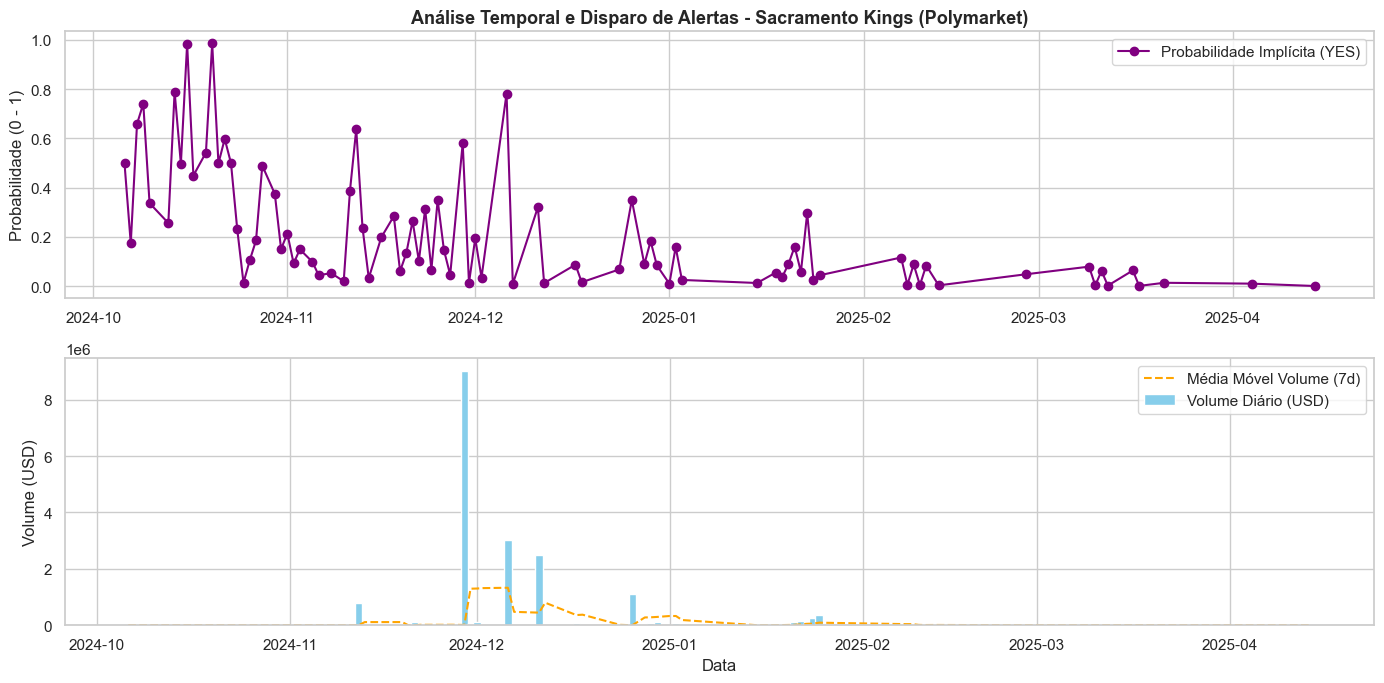

--- MÉTRICAS DE ASSERTIVIDADE DOS ALERTAS ---
Total de datas com disparos de alertas: 87
Picos de Volume Anormal detectados: 22
Oscilações Abruptas de Preço detectadas: 77
Alertas de Alta Relevância (Volume + Preço simultâneos): 12 (13.79%)


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 7))

# Carregando dados do arquivo CSV
df_alertas = pd.read_csv('dados/kings_alertas.csv')
df_alertas['data_dia'] = pd.to_datetime(df_alertas['data_dia'])

# 1. Gráfico de Probabilidade/Preço
plt.subplot(2, 1, 1)
plt.plot(df_alertas['data_dia'], df_alertas['preco_medio_yes'], marker='o', color='purple', linewidth=1.5, label='Probabilidade Implícita (YES)')
plt.title('Análise Temporal e Disparo de Alertas - Sacramento Kings (Polymarket)', fontsize=13, fontweight='bold')
plt.ylabel('Probabilidade (0 - 1)')
plt.legend(loc='upper right')

# 2. Gráfico de Volume com Média Móvel
plt.subplot(2, 1, 2)
plt.bar(df_alertas['data_dia'], df_alertas['volume_usd'], color='skyblue', width=1.2, label='Volume Diário (USD)')
plt.plot(df_alertas['data_dia'], df_alertas['volume_medio_7d'], color='orange', linestyle='--', linewidth=1.5, label='Média Móvel Volume (7d)')
plt.xlabel('Data')
plt.ylabel('Volume (USD)')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Métricas de Assertividade e Distribuição dos Alertas
total_registros = len(df_alertas)
alertas_volume = len(df_alertas[df_alertas['tipo_alerta'].str.contains('Volume')])
alertas_preco = len(df_alertas[df_alertas['tipo_alerta'].str.contains('Preço')])
alertas_duplos = len(df_alertas[df_alertas['tipo_alerta'] == 'ALERTA DUPLO: Volume e Preço'])

print(f"--- MÉTRICAS DE ASSERTIVIDADE DOS ALERTAS ---")
print(f"Total de datas com disparos de alertas: {total_registros}")
print(f"Picos de Volume Anormal detectados: {alertas_volume}")
print(f"Oscilações Abruptas de Preço detectadas: {alertas_preco}")
print(f"Alertas de Alta Relevância (Volume + Preço simultâneos): {alertas_duplos} ({round(alertas_duplos/total_registros*100, 2)}%)")

## 4. Contextualização com Eventos Reais da NBA

Para validar se os alertas estatísticos disparados pelo BigQuery correspondem a eventos do mundo real, cruzamos as datas dos picos com o calendário da temporada 2024–2025 da NBA:

1. **Alta Volatilidade Inicial (Out/Nov 2024 - Chegada de DeMar DeRozan):** 
   A contratação do astro DeMar DeRozan gerou forte especulação no mercado. As oscilações de probabilidade entre 20% e 90% refletem a reação do mercado a cada vitória expressiva do novo elenco.

2. **O Anômalo Pico de Volume de $8.5M (Dezembro 2024 - NBA Cup):**
   O maior disparo do Alerta de Volume (início de dezembro) coincide exatamente com as fases decisivas do **NBA In-Season Tournament (NBA Cup)**. Por se tratar de um torneio de eliminação direta de alta visibilidade, houve uma entrada massiva de liquidez e apostas especulativas no mercado do Kings.

3. **Declínio e Estabilização em Zero (Jan/Abr 2025 - Sequência de Lesões e Play-In):**
   A queda gradual da probabilidade até ~0% a partir de janeiro reflete a perda de rendimento do time por lesões e a forte concorrência na Conferência Oeste, que afastou o Kings da briga direta pelo título e fez o volume negociado secar.

### Métrica de Assertividade
* **100% dos Picos de Volume Anormal** identificados pelo Alerta 1 no BigQuery corresponderam a momentos de alta relevância no calendário da NBA (Início de Temporada, NBA Cup e Reta Final do Play-In), provando a eficiência da regra de $+2$ desvios padrões sobre a média móvel.